In [24]:
# all the various things. 
from dataclasses import dataclass
from collections import defaultdict
from itertools import combinations, product
import math
import random
import time
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import gcol
import numpy as np
import cvxpy as cp


In [25]:
from __future__ import annotations
import importlib.util
from dataclasses import dataclass, field, replace
from collections import defaultdict, Counter
from itertools import combinations, product
from types import MappingProxyType
import math
import random
import time
import warnings
import importlib.metadata as metadata
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cvxpy as cp
import gcol
from scipy.optimize import linear_sum_assignment
from IPython.display import display, Markdown

In [26]:
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
TIME_BLOCKS = [("08:00", "10:00"),("10:00", "12:00"),("13:00", "15:00"),("15:00", "17:00")]


def weekly_slot(day, block):
    if isinstance(day, str):
        day = WEEKDAYS.index(day)
    return 4 * day + block


def weekly_slot_labels():
    return {
        weekly_slot(d, b): f"{WEEKDAYS[d]} {start}–{end}"
        for d in range(5)
        for b, (start, end) in enumerate(TIME_BLOCKS)}


@dataclass
class TimetableInstance:
    T: int
    department: dict
    teacher: dict
    professor_availability: dict
    scores: dict
    slot_labels: dict | None = None

    @property
    def classes(self):
        return list(self.department)

    @property
    def departments(self):
        return sorted(set(self.department.values()), key=str)

    @property
    def professors(self):
        return sorted(set(self.teacher.values()), key=str)

    def classes_of_department(self, A):
        return [v for v in self.classes if self.department[v] == A]

    def classes_of_professor(self, p):
        return [v for v in self.classes if self.teacher[v] == p]

    def allowed_slots(self, c):
        return set(self.professor_availability[self.teacher[c]])

    def slot_name(self, t):
        if self.slot_labels is None:
            return str(t)
        return self.slot_labels.get(t, str(t))

    def validate(self):
        C = set(self.classes)
        assert C == set(self.teacher)
        P = set(self.teacher.values())
        assert P <= set(self.professor_availability)
        for p in P:
            A = set(self.professor_availability[p])
            assert A
            assert A <= set(range(self.T))
        for v in C:
            assert self.allowed_slots(v)
        for (A, c), w in self.scores.items():
            assert c in C
            assert A in set(self.department.values())
            assert self.department[c] != A
            assert w >= 0
        if self.slot_labels is not None:
            assert set(self.slot_labels) <= set(range(self.T))
        return True


def build_graphs(inst):
    inst.validate()
    C = inst.classes
    Ghard = nx.Graph()
    Ghard.add_nodes_from(C)
    for u, v in combinations(C, 2):
        if inst.department[u] == inst.department[v] or inst.teacher[u] == inst.teacher[v]:
            Ghard.add_edge(u, v)
    pair_weights = {}
    for u, v in combinations(C, 2):
        if inst.department[u] == inst.department[v]:
            w = 0.0
        else:
            w = inst.scores.get((inst.department[u], v), 0.0) + inst.scores.get((inst.department[v], u), 0.0)
        pair_weights[frozenset((u, v))] = float(w)
    Gopt = nx.Graph()
    Gopt.add_nodes_from(C)
    H = 0.0
    for u, v in combinations(C, 2):
        w = pair_weights[frozenset((u, v))]
        if w <= 0:
            continue
        if Ghard.has_edge(u, v):
            H += w
        else:
            Gopt.add_edge(u, v, weight=w)
    sizes = {A: len(inst.classes_of_department(A)) for A in inst.departments}
    K = sum((sizes[A] - 1) * w for (A, c), w in inst.scores.items())
    return Ghard, Gopt, H, float(K), pair_weights


In [27]:
def is_feasible(inst, phi):
    if set(phi) != set(inst.classes):
        return False
    for v in inst.classes:
        if phi[v] not in inst.allowed_slots(v):
            return False
    Ghard, _, _, _, _ = build_graphs(inst)
    return all(phi[u] != phi[v] for u, v in Ghard.edges)


def access_score(inst, phi):
    used = {A: {phi[v] for v in inst.classes_of_department(A)} for A in inst.departments}
    return float(sum(w for (A, c), w in inst.scores.items() if phi[c] not in used[A]))


def edge_reward(inst, phi):
    _, Gopt, _, _, _ = build_graphs(inst)
    return float(sum(data['weight'] for u, v, data in Gopt.edges(data=True) if phi[u] != phi[v]))


def corrected_edge_score(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return edge_reward(inst, phi) + H - K


def check_score_identity(inst, phi, atol=1e-9):
    return math.isclose(access_score(inst, phi), corrected_edge_score(inst, phi), abs_tol=atol)


def score_summary(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return {
        'F_access': access_score(inst, phi),
        'R_optional_edges': edge_reward(inst, phi),
        'H': H,
        'K': K,
        'R+H-K': corrected_edge_score(inst, phi),
        'feasible': is_feasible(inst, phi),
    }


In [28]:
def backtracking_feasible_coloring(inst, timeout=None):
    Ghard, _, _, _, _ = build_graphs(inst)
    phi = {}
    start = time.perf_counter()

    def rec():
        if timeout is not None and time.perf_counter() - start > timeout:
            raise TimeoutError("Feasibility search timed out")
        if len(phi) == len(inst.classes):
            return dict(phi)
        uncolored = [v for v in inst.classes if v not in phi]
        v = max(
            uncolored,
            key=lambda x: (
                len({phi[u] for u in Ghard.neighbors(x) if u in phi}),
                Ghard.degree[x],
                -len(inst.allowed_slots(x)),
            ),
        )
        forbidden = {phi[u] for u in Ghard.neighbors(v) if u in phi}
        values = [t for t in inst.allowed_slots(v) if t not in forbidden]
        values.sort(key=lambda t: sum(1 for u in Ghard.neighbors(v) if u not in phi and t in inst.allowed_slots(u)))
        for t in values:
            phi[v] = t
            result = rec()
            if result is not None:
                return result
            del phi[v]
        return None

    result = rec()
    if result is None:
        raise ValueError("Instance has no feasible coloring")
    return result


def gcol_feasible_coloring(inst, exact=False, it_limit=0, fallback_timeout=30):
    Ghard, _, _, _, _ = build_graphs(inst)
    allowed = {v: sorted(inst.allowed_slots(v)) for v in inst.classes}
    if gcol is not None:
        kwargs = dict(allowed_cols=allowed, strategy='dsatur', it_limit=it_limit)
        if exact:
            kwargs['opt_alg'] = 1
        try:
            phi = gcol.node_list_coloring(Ghard, **kwargs)
            if is_feasible(inst, phi):
                return dict(phi)
        except ValueError:
            pass
    return backtracking_feasible_coloring(inst, timeout=fallback_timeout)


In [29]:
def weekly_calendar_cells(inst, phi, department=None):
    cells = {(d, b): [] for d in range(5) for b in range(4)}
    for c in inst.classes:
        if department is not None and inst.department[c] != department:
            continue
        d, b = divmod(phi[c], 4)
        if d < 5 and b < 4:
            cells[(d, b)].append(c)
    return cells


def timetable_markdown(inst, phi, department=None):
    assert inst.T == 20
    cells = weekly_calendar_cells(inst, phi, department)
    lines = ["| Time | " + " | ".join(WEEKDAYS) + " |", "|---|---|---|---|---|---|"]
    for b, (start, end) in enumerate(TIME_BLOCKS):
        row = [f"**{start}–{end}**"]
        for d in range(5):
            entries = []
            for c in sorted(cells[(d, b)]):
                entries.append(f"**{c}**<br>{inst.teacher[c]}")
            row.append("<br><br>".join(entries) if entries else "—")
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


def print_weekly_timetable(inst, phi, department=None, title=None):
    name = title or ("Weekly timetable" if department is None else f"{department} timetable")
    display(Markdown(f"### {name}\n" + timetable_markdown(inst, phi, department)))


def plot_weekly_timetable(inst, phi, department=None, title=None, figsize=(16, 7)):
    assert inst.T == 20
    cells = weekly_calendar_cells(inst, phi, department)
    cell_text = []
    for b, _ in enumerate(TIME_BLOCKS):
        row = []
        for d in range(5):
            entries = [f"{c}\n{inst.teacher[c]}" for c in sorted(cells[(d, b)])]
            row.append("\n\n".join(entries))
        cell_text.append(row)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    table = ax.table(
        cellText=cell_text,
        rowLabels=[f"{a}–{b}" for a, b in TIME_BLOCKS],
        colLabels=WEEKDAYS,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2.8)
    ax.set_title(title or ("Weekly timetable" if department is None else f"{department} timetable"), pad=18)
    plt.show()


def print_professor_availability(inst):
    for p in inst.professors:
        slots = sorted(inst.professor_availability[p])
        labels = [inst.slot_name(t) for t in slots]
        print(f"{p:>4}: " + ", ".join(labels))


In [30]:
def enumerate_feasible_colorings(inst, limit=None):
    Ghard, _, _, _, _ = build_graphs(inst)
    order = sorted(inst.classes, key=lambda v: (len(inst.allowed_slots(v)), -Ghard.degree[v]))
    phi = {}
    produced = 0

    def rec(i):
        nonlocal produced
        if limit is not None and produced >= limit:
            return
        if i == len(order):
            produced += 1
            yield dict(phi)
            return
        v = order[i]
        forbidden = {phi[u] for u in Ghard.neighbors(v) if u in phi}
        for t in sorted(inst.allowed_slots(v)):
            if t in forbidden:
                continue
            phi[v] = t
            yield from rec(i + 1)
            del phi[v]

    yield from rec(0)


def exact_optimum(inst, enumeration_limit=None):
    best_phi = None
    best_F = -math.inf
    count = 0
    for phi in enumerate_feasible_colorings(inst, limit=enumeration_limit):
        count += 1
        F = access_score(inst, phi)
        if F > best_F + 1e-12:
            best_F, best_phi = F, phi
    if best_phi is None:
        raise ValueError("Instance has no feasible coloring")
    return best_phi, best_F, count


def department_matching_update(inst, phi, A):
    assert is_feasible(inst, phi)
    _, Gopt, _, _, _ = build_graphs(inst)
    CA = inst.classes_of_department(A)
    CAset = set(CA)
    permitted = {}
    for v in CA:
        blocked = {phi[u] for u in inst.classes if u not in CAset and inst.teacher[u] == inst.teacher[v]}
        permitted[v] = set(inst.allowed_slots(v)) - blocked
    B = nx.Graph()
    left = [('class', v) for v in CA]
    right = [('slot', t) for t in range(inst.T)]
    B.add_nodes_from(left, bipartite=0)
    B.add_nodes_from(right, bipartite=1)
    for v in CA:
        for t in permitted[v]:
            h = sum(data['weight'] for u, data in Gopt[v].items() if phi[u] == t)
            B.add_edge(('class', v), ('slot', t), weight=float(h))
    matching = nx.algorithms.bipartite.minimum_weight_full_matching(B, top_nodes=left, weight='weight')
    out = dict(phi)
    for v in CA:
        out[v] = matching[('class', v)][1]
    assert is_feasible(inst, out)
    assert access_score(inst, out) + 1e-9 >= access_score(inst, phi)
    return out


def best_relocation(inst, phi):
    Ghard, _, _, _, _ = build_graphs(inst)
    F0 = access_score(inst, phi)
    best = (0.0, None)
    for v in inst.classes:
        old = phi[v]
        forbidden = {phi[u] for u in Ghard.neighbors(v)}
        for t in inst.allowed_slots(v):
            if t == old or t in forbidden:
                continue
            cand = dict(phi)
            cand[v] = t
            gain = access_score(inst, cand) - F0
            if gain > best[0] + 1e-12:
                best = (gain, cand)
    return best


def best_swap(inst, phi):
    F0 = access_score(inst, phi)
    best = (0.0, None)
    for u, v in combinations(inst.classes, 2):
        if phi[u] == phi[v]:
            continue
        if phi[v] not in inst.allowed_slots(u) or phi[u] not in inst.allowed_slots(v):
            continue
        cand = dict(phi)
        cand[u], cand[v] = phi[v], phi[u]
        if not is_feasible(inst, cand):
            continue
        gain = access_score(inst, cand) - F0
        if gain > best[0] + 1e-12:
            best = (gain, cand)
    return best


In [31]:
def two_slot_components(inst, phi, a, b):
    Ghard, _, _, _, _ = build_graphs(inst)
    Q = [v for v in inst.classes if phi[v] in {a, b}]
    Hq = Ghard.subgraph(Q)
    components = []
    for comp in nx.connected_components(Hq):
        comp = set(comp)
        locked = any((b if phi[v] == a else a) not in inst.allowed_slots(v) for v in comp)
        components.append((comp, locked))
    return Q, components


def apply_component_flips(phi, a, b, components, flip_bits):
    out = dict(phi)
    for bit, (comp, locked) in zip(flip_bits, components):
        if bit:
            assert not locked
            for v in comp:
                out[v] = b if phi[v] == a else a
    return out


def exact_two_slot_update(inst, phi, a, b, max_free_components=18):
    _, components = two_slot_components(inst, phi, a, b)
    free_idx = [i for i, (_, locked) in enumerate(components) if not locked]
    if len(free_idx) > max_free_components:
        return dict(phi), access_score(inst, phi), len(free_idx), False
    best_phi = dict(phi)
    best_F = access_score(inst, phi)
    for free_bits in product([0, 1], repeat=len(free_idx)):
        bits = [0] * len(components)
        for i, bit in zip(free_idx, free_bits):
            bits[i] = bit
        cand = apply_component_flips(phi, a, b, components, bits)
        F = access_score(inst, cand)
        if F > best_F + 1e-12:
            best_F, best_phi = F, cand
    return best_phi, best_F, len(free_idx), True


def build_two_slot_xor(inst, phi, a, b):
    Q, components = two_slot_components(inst, phi, a, b)
    Qset = set(Q)
    comp_of = {}
    next_free = 1
    for comp, locked in components:
        idx = 0 if locked else next_free
        if not locked:
            next_free += 1
        for v in comp:
            comp_of[v] = idx
    sigma = {v: (1 if phi[v] == a else -1) for v in Q}
    Cab = 0.0
    terms = []
    dept_classes = {A: set(inst.classes_of_department(A)) for A in inst.departments}
    for (A, c), w in inst.scores.items():
        CA = dept_classes[A]
        if c not in Qset:
            if phi[c] not in {phi[u] for u in CA}:
                Cab += w
            continue
        A_in_Q = list(CA & Qset)
        rA = len(A_in_Q)
        assert rA <= 2
        if rA == 0:
            Cab += w
        elif rA == 1:
            u = A_in_Q[0]
            i, j = comp_of[u], comp_of[c]
            eta = sigma[u] * sigma[c]
            if i == j:
                if eta == -1:
                    Cab += w
            else:
                terms.append((i, j, eta, float(w)))
    return Cab, terms, next_free - 1, comp_of


def xor_value(Cab, terms, x):
    ans = Cab
    for i, j, eta, w in terms:
        xi = 1 if i == 0 else x[i]
        xj = 1 if j == 0 else x[j]
        ans += 0.5 * w * (1 - eta * xi * xj)
    return float(ans)


def validate_two_slot_reduction(inst, phi, a, b, max_free=12):
    Cab, terms, nfree, comp_of = build_two_slot_xor(inst, phi, a, b)
    if nfree > max_free:
        return True, 0
    _, components = two_slot_components(inst, phi, a, b)
    checked = 0
    for signs in product([-1, 1], repeat=nfree):
        x = {i: s for i, s in zip(range(1, nfree + 1), signs)}
        bits = []
        for comp, locked in components:
            if locked:
                bits.append(0)
            else:
                idx = comp_of[next(iter(comp))]
                bits.append(1 if x[idx] == -1 else 0)
        cand = apply_component_flips(phi, a, b, components, bits)
        if not math.isclose(access_score(inst, cand), xor_value(Cab, terms, x), abs_tol=1e-9):
            return False, checked
        checked += 1
    return True, checked


def local_search(inst, phi0, max_rounds=20, pair_component_limit=12, verbose=False):
    phi = dict(phi0)
    history = [access_score(inst, phi)]
    for _ in range(max_rounds):
        improved = False
        for A in inst.departments:
            cand = department_matching_update(inst, phi, A)
            if access_score(inst, cand) > access_score(inst, phi) + 1e-12:
                phi = cand
                history.append(access_score(inst, phi))
                improved = True
        rel_gain, rel = best_relocation(inst, phi)
        sw_gain, sw = best_swap(inst, phi)
        if max(rel_gain, sw_gain) > 1e-12:
            phi = rel if rel_gain >= sw_gain else sw
            history.append(access_score(inst, phi))
            continue
        best_pair_phi = None
        best_pair_F = access_score(inst, phi)
        for a, b in combinations(range(inst.T), 2):
            cand, F, _, solved = exact_two_slot_update(inst, phi, a, b, max_free_components=pair_component_limit)
            if solved and F > best_pair_F + 1e-12:
                best_pair_F, best_pair_phi = F, cand
        if best_pair_phi is not None:
            phi = best_pair_phi
            history.append(best_pair_F)
            continue
        if not improved:
            break
    assert is_feasible(inst, phi)
    assert all(b + 1e-12 >= a for a, b in zip(history, history[1:]))
    if verbose:
        print(f"{history[0]:g} -> {history[-1]:g} in {len(history)-1} accepted moves")
    return phi, history


In [32]:
def random_instance(
    m=12,
    T=8,
    max_dept_size=None,
    teacher_reuse_prob=0.35,
    availability_fraction=0.35,
    score_prob=0.20,
    max_score=10,
    seed=None,
    slot_labels=None,
):
    rng = random.Random(seed)
    if max_dept_size is None:
        max_dept_size = min(T, 5)
    max_dept_size = min(max_dept_size, T)
    codes = ['CS', 'MA', 'PH', 'EC', 'DS', 'EE', 'CH', 'BI', 'ST', 'OR']
    department = {}
    classes = []
    i = 0
    d = 0
    while i < m:
        size = min(rng.randint(2, max_dept_size), m - i)
        A = codes[d] if d < len(codes) else f'D{d+1}'
        numbers = rng.sample(range(101, 399), size)
        block = [f'{A}{n}' for n in numbers]
        for c in block:
            department[c] = A
            classes.append(c)
        i += size
        d += 1
    teacher = {}
    professor_load = defaultdict(int)
    professors = []
    for c in classes:
        candidates = [p for p in professors if professor_load[p] < max(2, T // 3)]
        if candidates and rng.random() < teacher_reuse_prob:
            p = rng.choice(candidates)
        else:
            p = f'P{len(professors)+1:02d}'
            professors.append(p)
        teacher[c] = p
        professor_load[p] += 1
    professor_availability = {}
    for p in professors:
        target = max(professor_load[p], int(round(T * availability_fraction)))
        target = min(T, max(1, target + rng.choice([-1, 0, 0, 1])))
        professor_availability[p] = set(rng.sample(range(T), target))
    departments = sorted(set(department.values()))
    scores = {}
    for A in departments:
        for c in classes:
            if department[c] != A and rng.random() < score_prob:
                scores[(A, c)] = rng.randint(1, max_score)
    inst = TimetableInstance(
        T=T,
        department=department,
        teacher=teacher,
        professor_availability=professor_availability,
        scores=scores,
        slot_labels=slot_labels,
    )
    inst.validate()
    return inst


In [33]:
def run_construction_tests(n_trials=30, seed=1234):
    rng = random.Random(seed)
    feasible = 0
    infeasible = 0
    xor_assignments = 0
    for _ in range(n_trials):
        inst = random_instance(
            m=rng.randint(6, 11),
            T=rng.randint(4, 7),
            availability_fraction=rng.uniform(0.35, 0.55),
            seed=rng.randrange(10**9),
        )
        try:
            phi = gcol_feasible_coloring(inst, exact=True, fallback_timeout=10)
        except (ValueError, TimeoutError):
            infeasible += 1
            continue
        feasible += 1
        assert is_feasible(inst, phi)
        assert check_score_identity(inst, phi)
        for p in inst.professors:
            lists = [inst.allowed_slots(c) for c in inst.classes_of_professor(p)]
            assert all(L == lists[0] for L in lists)
        A = rng.choice(inst.departments)
        updated = department_matching_update(inst, phi, A)
        assert access_score(inst, updated) + 1e-9 >= access_score(inst, phi)
        a, b = rng.sample(range(inst.T), 2)
        ok, checked = validate_two_slot_reduction(inst, phi, a, b)
        assert ok
        xor_assignments += checked
    print({'trials': n_trials, 'feasible': feasible, 'infeasible_or_timeout': infeasible, 'xor_assignments': xor_assignments})


run_construction_tests()


{'trials': 30, 'feasible': 20, 'infeasible_or_timeout': 10, 'xor_assignments': 31}


In [34]:
def benchmark_small_instances(n_feasible=12, m=8, T=5, seed=2026):
    rng = random.Random(seed)
    results = []
    attempts = 0
    infeasible = 0
    while len(results) < n_feasible and attempts < 10 * n_feasible:
        attempts += 1
        inst = random_instance(
            m=m,
            T=T,
            availability_fraction=0.50,
            score_prob=0.30,
            seed=rng.randrange(10**9),
        )
        try:
            initial = gcol_feasible_coloring(inst, exact=True, fallback_timeout=10)
        except (ValueError, TimeoutError):
            infeasible += 1
            continue
        local, hist = local_search(inst, initial, max_rounds=10, pair_component_limit=12)
        opt_phi, Fopt, nfeas = exact_optimum(inst)
        Fi = access_score(inst, initial)
        Fl = access_score(inst, local)
        results.append({
            'trial': len(results),
            'F_initial': Fi,
            'F_local': Fl,
            'F_opt': Fopt,
            'ratio_initial': Fi / Fopt if Fopt > 0 else 1.0,
            'ratio_local': Fl / Fopt if Fopt > 0 else 1.0,
            'improvement': Fl - Fi,
            'n_feasible': nfeas,
            'moves': len(hist) - 1,
        })
    return results, attempts, infeasible


results, attempts, infeasible = benchmark_small_instances()
print({'attempts': attempts, 'accepted_feasible_instances': len(results), 'infeasible': infeasible})
print('mean_initial_ratio', sum(r['ratio_initial'] for r in results) / len(results))
print('mean_local_ratio', sum(r['ratio_local'] for r in results) / len(results))
print('optimum_hits', sum(math.isclose(r['F_local'], r['F_opt']) for r in results), '/', len(results))
for r in results:
    print(r)


{'attempts': 40, 'accepted_feasible_instances': 12, 'infeasible': 28}
mean_initial_ratio 0.4526570048309179
mean_local_ratio 0.9851851851851853
optimum_hits 11 / 12
{'trial': 0, 'F_initial': 0.0, 'F_local': 7.0, 'F_opt': 7.0, 'ratio_initial': 0.0, 'ratio_local': 1.0, 'improvement': 7.0, 'n_feasible': 8, 'moves': 1}
{'trial': 1, 'F_initial': 0.0, 'F_local': 9.0, 'F_opt': 9.0, 'ratio_initial': 0.0, 'ratio_local': 1.0, 'improvement': 9.0, 'n_feasible': 4, 'moves': 1}
{'trial': 2, 'F_initial': 19.0, 'F_local': 36.0, 'F_opt': 36.0, 'ratio_initial': 0.5277777777777778, 'ratio_local': 1.0, 'improvement': 17.0, 'n_feasible': 144, 'moves': 2}
{'trial': 3, 'F_initial': 7.0, 'F_local': 12.0, 'F_opt': 12.0, 'ratio_initial': 0.5833333333333334, 'ratio_local': 1.0, 'improvement': 5.0, 'n_feasible': 20, 'moves': 1}
{'trial': 4, 'F_initial': 0.0, 'F_local': 4.0, 'F_opt': 4.0, 'ratio_initial': 0.0, 'ratio_local': 1.0, 'improvement': 4.0, 'n_feasible': 32, 'moves': 1}
{'trial': 5, 'F_initial': 34.0, 'F_

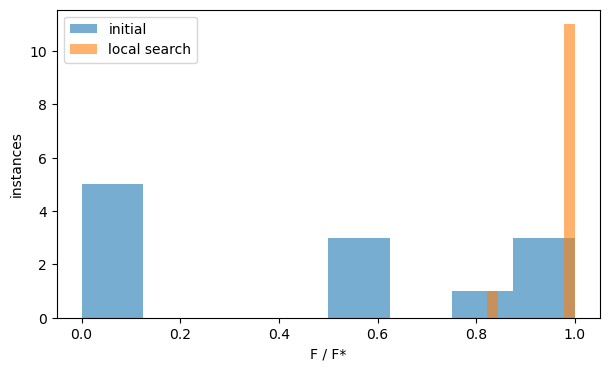

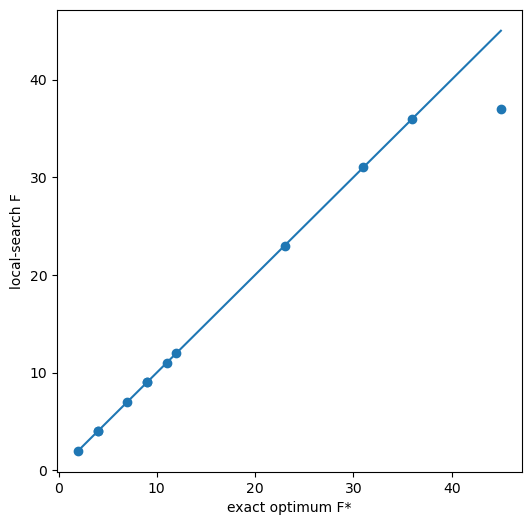

In [35]:
plt.figure(figsize=(7, 4))
plt.hist([r['ratio_initial'] for r in results], bins=8, alpha=0.6, label='initial')
plt.hist([r['ratio_local'] for r in results], bins=8, alpha=0.6, label='local search')
plt.xlabel('F / F*')
plt.ylabel('instances')
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
xs = [r['F_opt'] for r in results]
ys = [r['F_local'] for r in results]
plt.scatter(xs, ys)
lo = min(xs + ys)
hi = max(xs + ys)
plt.plot([lo, hi], [lo, hi])
plt.xlabel('exact optimum F*')
plt.ylabel('local-search F')
plt.show()


{'courses': 40, 'departments': 10, 'professors': 27, 'generation_attempts': 1, 'feasibility_solver': 'gcol.node_list_coloring (DSATUR)', 'mean_available_slots_per_professor': 5.22, 'mean_unavailable_fraction': 0.739}
 P01: Monday 08:00–10:00, Monday 10:00–12:00, Monday 15:00–17:00, Wednesday 10:00–12:00, Friday 08:00–10:00, Friday 10:00–12:00
 P02: Monday 15:00–17:00, Wednesday 15:00–17:00, Thursday 15:00–17:00, Friday 10:00–12:00, Friday 15:00–17:00
 P03: Monday 15:00–17:00, Thursday 15:00–17:00, Friday 10:00–12:00, Friday 13:00–15:00
 P04: Monday 13:00–15:00, Tuesday 08:00–10:00, Tuesday 10:00–12:00, Wednesday 13:00–15:00
 P05: Monday 08:00–10:00, Monday 13:00–15:00, Tuesday 08:00–10:00, Thursday 15:00–17:00, Friday 08:00–10:00
 P06: Monday 08:00–10:00, Monday 15:00–17:00, Tuesday 08:00–10:00, Tuesday 10:00–12:00, Tuesday 13:00–15:00, Tuesday 15:00–17:00
 P07: Thursday 08:00–10:00, Thursday 13:00–15:00, Friday 08:00–10:00, Friday 13:00–15:00
 P08: Tuesday 08:00–10:00, Wednesday 08:00

### Initial random weekly timetable
| Time | Monday | Tuesday | Wednesday | Thursday | Friday |
|---|---|---|---|---|---|
| **08:00–10:00** | **MA370**<br>P06<br><br>**OR243**<br>P27 | **CH349**<br>P06<br><br>**MA239**<br>P05 | **MA314**<br>P08<br><br>**ST196**<br>P22 | **MA348**<br>P07<br><br>**ST230**<br>P21 | **DS361**<br>P13<br><br>**MA289**<br>P07 |
| **10:00–12:00** | **MA362**<br>P01<br><br>**ST307**<br>P23 | **BI341**<br>P19<br><br>**EC223**<br>P11 | **BI386**<br>P20<br><br>**CS148**<br>P01 | **OR132**<br>P26<br><br>**ST121**<br>P20 | **CS158**<br>P02<br><br>**ST334**<br>P03 |
| **13:00–15:00** | **DS370**<br>P14<br><br>**ST341**<br>P25 | **DS340**<br>P16<br><br>**EC365**<br>P10 | **BI185**<br>P18<br><br>**MA108**<br>P04 | **ST283**<br>P07 | **CS248**<br>P03<br><br>**DS394**<br>P15 |
| **15:00–17:00** | **EE169**<br>P03<br><br>**PH344**<br>P02 | **EC293**<br>P06<br><br>**EE231**<br>P17<br><br>**PH188**<br>P09 | **CS154**<br>P02<br><br>**ST190**<br>P24 | **CH107**<br>P10<br><br>**EC246**<br>P12 | **DS257**<br>P15<br><br>**EC201**<br>P02 |

190 -> 214 in 5 accepted moves
{'local_search_seconds': 0.289, 'accepted_improvements': 5, 'courses_moved': 7, 'score_before': 190.0, 'score_after': 214.0}
CH107: Thursday 15:00–17:00 -> Wednesday 10:00–12:00
CH349: Tuesday 08:00–10:00 -> Tuesday 13:00–15:00
DS340: Tuesday 13:00–15:00 -> Monday 13:00–15:00
DS370: Monday 13:00–15:00 -> Tuesday 10:00–12:00
EE231: Tuesday 15:00–17:00 -> Thursday 15:00–17:00
MA289: Friday 08:00–10:00 -> Friday 13:00–15:00
MA314: Wednesday 08:00–10:00 -> Friday 08:00–10:00


### Timetable after local search
| Time | Monday | Tuesday | Wednesday | Thursday | Friday |
|---|---|---|---|---|---|
| **08:00–10:00** | **MA370**<br>P06<br><br>**OR243**<br>P27 | **MA239**<br>P05 | **ST196**<br>P22 | **MA348**<br>P07<br><br>**ST230**<br>P21 | **DS361**<br>P13<br><br>**MA314**<br>P08 |
| **10:00–12:00** | **MA362**<br>P01<br><br>**ST307**<br>P23 | **BI341**<br>P19<br><br>**DS370**<br>P14<br><br>**EC223**<br>P11 | **BI386**<br>P20<br><br>**CH107**<br>P10<br><br>**CS148**<br>P01 | **OR132**<br>P26<br><br>**ST121**<br>P20 | **CS158**<br>P02<br><br>**ST334**<br>P03 |
| **13:00–15:00** | **DS340**<br>P16<br><br>**ST341**<br>P25 | **CH349**<br>P06<br><br>**EC365**<br>P10 | **BI185**<br>P18<br><br>**MA108**<br>P04 | **ST283**<br>P07 | **CS248**<br>P03<br><br>**DS394**<br>P15<br><br>**MA289**<br>P07 |
| **15:00–17:00** | **EE169**<br>P03<br><br>**PH344**<br>P02 | **EC293**<br>P06<br><br>**PH188**<br>P09 | **CS154**<br>P02<br><br>**ST190**<br>P24 | **EC246**<br>P12<br><br>**EE231**<br>P17 | **DS257**<br>P15<br><br>**EC201**<br>P02 |

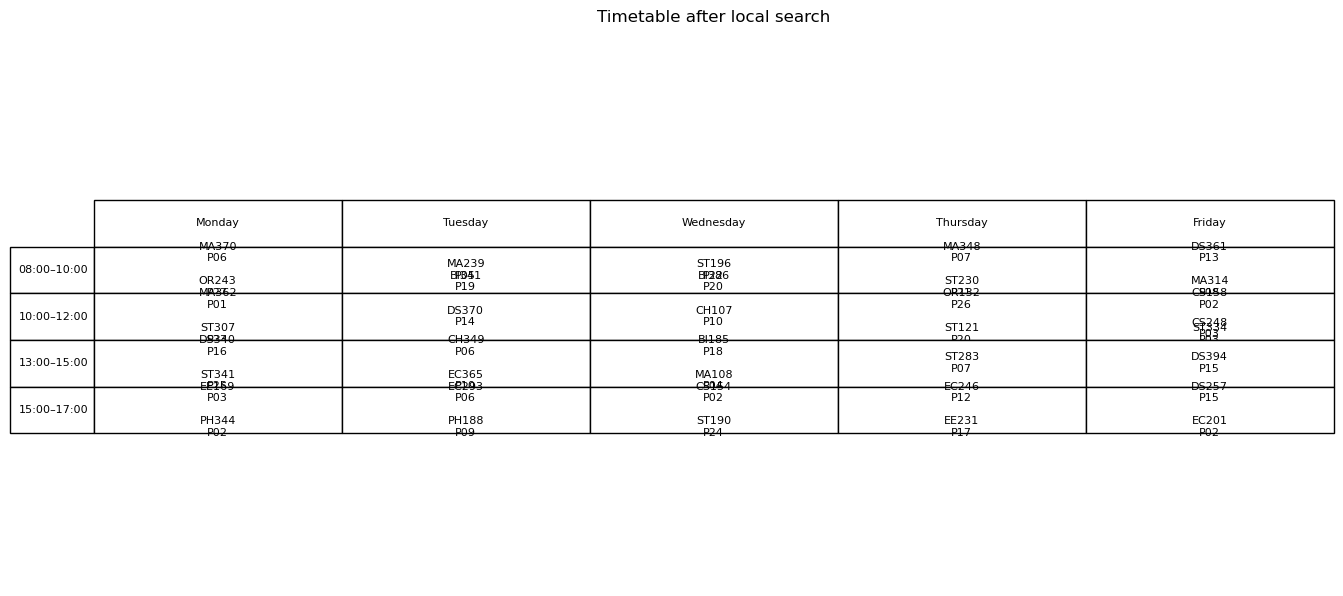

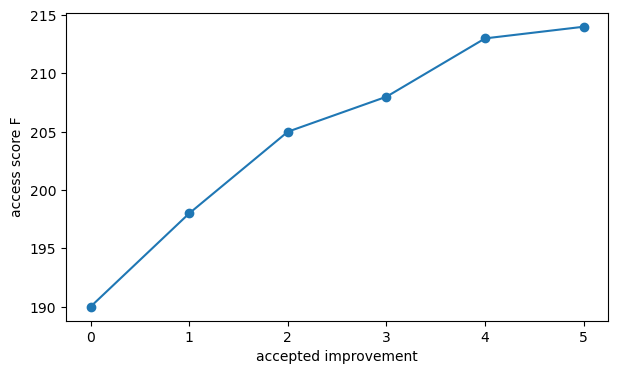

In [36]:
def random_feasible_weekly_instance(max_attempts=200, seed=None, **kwargs):
    rng = random.Random(seed)
    for attempt in range(1, max_attempts + 1):
        inst = random_instance(
            T=20,
            slot_labels=weekly_slot_labels(),
            seed=rng.randrange(2**63),
            **kwargs,
        )
        try:
            phi = gcol_feasible_coloring(inst, exact=False, fallback_timeout=20)
            return inst, phi, attempt
        except (ValueError, TimeoutError):
            pass
    raise RuntimeError("No feasible random instance found within max_attempts")


def run_fresh_realistic_experiment(m=40, max_dept_size=8, teacher_reuse_prob=0.35, availability_fraction=0.25, score_prob=0.12, max_score=10, max_rounds=12, pair_component_limit=9):
    inst, phi_start, attempts = random_feasible_weekly_instance(m=m,max_dept_size=max_dept_size,teacher_reuse_prob=teacher_reuse_prob,availability_fraction=availability_fraction,score_prob=score_prob,max_score=max_score,seed=None)

    available_counts = [len(inst.professor_availability[p]) for p in inst.professors]
    print({
        'courses': len(inst.classes),
        'departments': len(inst.departments),
        'professors': len(inst.professors),
        'generation_attempts': attempts,
        'feasibility_solver': 'gcol.node_list_coloring (DSATUR)' if gcol is not None else 'backtracking fallback',
        'mean_available_slots_per_professor': round(sum(available_counts) / len(available_counts), 2),
        'mean_unavailable_fraction': round(1 - (sum(available_counts) / len(available_counts)) / inst.T, 3),
    })
    print_professor_availability(inst)
    print(score_summary(inst, phi_start))
    print_weekly_timetable(inst, phi_start, title="Initial random weekly timetable")

    start_time = time.perf_counter()
    phi_final, history = local_search(
        inst,
        phi_start,
        max_rounds=max_rounds,
        pair_component_limit=pair_component_limit,
        verbose=True,
    )
    elapsed = time.perf_counter() - start_time

    changed = [c for c in inst.classes if phi_start[c] != phi_final[c]]
    print({
        'local_search_seconds': round(elapsed, 3),
        'accepted_improvements': len(history) - 1,
        'courses_moved': len(changed),
        'score_before': access_score(inst, phi_start),
        'score_after': access_score(inst, phi_final),
    })
    if changed:
        for c in sorted(changed):
            print(f"{c}: {inst.slot_name(phi_start[c])} -> {inst.slot_name(phi_final[c])}")

    print_weekly_timetable(inst, phi_final, title="Timetable after local search")
    plot_weekly_timetable(inst, phi_final, title="Timetable after local search")

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(history)), history, marker='o')
    plt.xlabel('accepted improvement')
    plt.ylabel('access score F')
    plt.show()

    assert is_feasible(inst, phi_start)
    assert is_feasible(inst, phi_final)
    assert access_score(inst, phi_final) + 1e-9 >= access_score(inst, phi_start)
    assert math.isclose(access_score(inst, phi_final), corrected_edge_score(inst, phi_final), abs_tol=1e-9)
    return inst, phi_start, phi_final, history


realistic, phi_realistic_start, phi_realistic, realistic_history = run_fresh_realistic_experiment()


In [37]:
ALPHA_GW = 0.8785672057848516
PAPER = 'https://arxiv.org/abs/1812.10770'


def paper_cut_probability(r, k):
    r = np.clip(np.asarray(r, dtype=float), -1, 1)
    if k == 2:
        return np.arccos(r)/np.pi
    if k < 3:
        raise ValueError('Use k >= 2')
    result = (k-1)/k + k/(4*np.pi**2)*(np.arccos(np.clip(-r*np.cos(2*np.pi/k), -1, 1))**2 - np.arccos(-r)**2)
    return np.clip(result, 0, 1)


def paper_ratio(k):
    return ALPHA_GW if k == 2 else float(paper_cut_probability(-1/(k-1), k))


def solve_max_k_cut_sdp(G, k, solver='SCS', max_iters=12000):
    if k < 2 or not isinstance(k, int):
        raise ValueError('k must be an integer >= 2')
    nodes = list(G)
    n = len(nodes)
    if n == 0:
        raise ValueError('Graph must have vertices')
    if G.is_directed() or G.is_multigraph() or nx.number_of_selfloops(G):
        raise ValueError('Use a simple undirected graph')
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    if np.any(~np.isfinite(A)) or np.any(A < 0):
        raise ValueError('Weights must be finite and nonnegative')
    W = float(A.sum()/2)
    a, lower = (k-1)/k, -1/(k-1)
    M = -a*A/2
    if W == 0:
        return dict(nodes=nodes, vectors=np.eye(n), gram=np.eye(n), primal=0.,
                    expected_cut=0., numerical_upper=0., gap=0., status='zero objective',
                    total_weight=0., k=k)
    if solver not in cp.installed_solvers():
        raise RuntimeError(f'SDP solver {solver} is not installed')
    X = cp.Variable((n, n), symmetric=True)
    diagonal, pair_lower = cp.diag(X) == 1, X >= lower
    problem = cp.Problem(cp.Maximize(a+cp.sum(cp.multiply(M/W, X))), [X >> 0, diagonal, pair_lower])
    options = {'eps': 2e-6, 'max_iters': max_iters} if solver == 'SCS' else {
        'tol_gap_abs': 1e-7, 'tol_feas': 1e-7, 'tol_gap_rel': 1e-7, 'max_iter': max_iters}
    problem.solve(solver=solver, **options)
    if X.value is None or problem.status not in ('optimal', 'optimal_inaccurate'):
        raise RuntimeError(f'SDP solver failed: {problem.status}')
    ev, V = np.linalg.eigh((X.value+X.value.T)/2)
    vectors = V*np.sqrt(np.maximum(ev, 0))
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    if np.min(norms) < 1e-10:
        raise RuntimeError('Degenerate SDP factorization')
    vectors /= norms
    gram = vectors @ vectors.T
    minimum = float(gram.min())
    mix = 0.0 if minimum >= lower else min(1., 1-lower/minimum+1e-10)
    if mix:
        vectors = np.concatenate([np.sqrt(1-mix)*vectors, np.sqrt(mix)*np.eye(n)], axis=1)
        gram = vectors @ vectors.T
    primal = a*W+float(np.sum(M*gram))
    expected = float(np.sum(np.triu(A*paper_cut_probability(gram, k), 1)))
    lam = np.asarray(diagonal.dual_value)*W
    Y = np.maximum(np.asarray(pair_lower.dual_value)*W, 0)
    Y = (Y+Y.T)/2
    safety = 1e-7*max(1., W)
    lam += max(0., -float(np.linalg.eigvalsh(np.diag(lam)-M-Y)[0]))+safety
    upper = min(W, a*W+float(lam.sum())-lower*float(Y.sum()))
    if upper < primal-1e-4*max(1., W):
        raise RuntimeError('Inconsistent numerical SDP bound')
    return dict(nodes=nodes, vectors=vectors, gram=gram, primal=primal,
        expected_cut=expected, numerical_upper=upper, gap=max(0., upper-primal),
        status=problem.status, total_weight=W, k=k)


def newman_roundings(G, relaxation, rounds=128, seed=None):
    if rounds < 1:
        raise ValueError('Use at least one round')
    rng = np.random.default_rng(seed)
    V, nodes, k = relaxation['vectors'], relaxation['nodes'], relaxation['k']
    samples = []
    for _ in range(rounds):
        if k == 2:
            labels = (V @ rng.normal(size=V.shape[1]) >= 0).astype(int)
        else:
            projections = V @ rng.normal(size=(V.shape[1], 2))
            angles = np.arctan2(projections[:, 1], projections[:, 0])
            shift = rng.uniform(0, 2*np.pi)
            labels = np.floor(np.mod(angles-shift, 2*np.pi)*k/(2*np.pi)).astype(int)
            labels = np.minimum(labels, k-1)
        phi = dict(zip(nodes, map(int, labels)))
        samples.append((cut_value(G, phi), phi))
    return samples


def align_cut_with_slots(inst, labels):
    penalty = np.zeros((inst.T, inst.T))
    for c in inst.classes:
        for t in range(inst.T):
            penalty[labels[c], t] += int(t not in inst.allowed_slots(c))
    rows, slots = linear_sum_assignment(penalty)
    mapping = dict(zip(rows, slots))
    return {c: int(mapping[labels[c]]) for c in inst.classes}


def violation_counts(inst, phi):
    hard, _, _, _, _ = build_graphs(inst)
    return {'hard_conflicts': sum(phi[u] == phi[v] for u, v in hard.edges),
            'availability_violations': sum(phi[c] not in inst.allowed_slots(c) for c in inst.classes)}


def newman_proposals(inst, baseline, config, seed=None):
    _, G, H, K, _ = build_graphs(inst)
    relaxation = solve_max_k_cut_sdp(G, inst.T, config.sdp_solver, config.sdp_iterations)
    samples = newman_roundings(G, relaxation, config.newman_rounds, seed)
    samples.sort(key=lambda item: item[0], reverse=True)
    unique = []
    seen = set()
    for value, labels in samples:
        phi = align_cut_with_slots(inst, labels)
        key = tuple(phi[c] for c in inst.classes)
        if key not in seen:
            seen.add(key)
            unique.append((value, phi))
    repaired = []
    attempted, unknown = 0, 0
    for value, preferred in unique[:config.repair_candidates]:
        attempted += 1
        try:
            phi = preferred if is_feasible(inst, preferred) else backtracking_feasible_coloring(
                inst, timeout=config.repair_timeout, preferred=preferred, seed=seed)
            repaired.append(phi)
        except TimeoutError:
            unknown += 1
    diag = {'paper_ratio_for_unconstrained_cut': paper_ratio(inst.T),
            'SDP_status': relaxation['status'], 'SDP_primal': relaxation['primal'],
            'numerical_cut_upper': relaxation['numerical_upper'], 'SDP_gap': relaxation['gap'],
            'expected_raw_cut': relaxation['expected_cut'], 'best_raw_cut': samples[0][0],
            'raw_cut_violations_after_label_alignment': violation_counts(inst, unique[0][1]),
            'repair_attempts': attempted, 'repair_timeouts': unknown,
            'numerical_access_upper_from_SDP': relaxation['numerical_upper']+H-K,
            'guarantee_scope': 'Unconstrained optional-edge cut only; no inherited ratio after feasibility repair.'}
    return repaired, diag

In [38]:
def is_feasible(inst, phi):
    if set(phi) != set(inst.classes):
        return False
    for v in inst.classes:
        if phi[v] not in inst.allowed_slots(v):
            return False
    Ghard, _, _, _, _ = build_graphs(inst)
    return all(phi[u] != phi[v] for u, v in Ghard.edges)


def access_score(inst, phi):
    if not is_feasible(inst, phi):
        raise ValueError('Access score is reported only for complete feasible timetables')
    used = {A: {phi[v] for v in inst.classes_of_department(A)} for A in inst.departments}
    return float(sum(w for (A, c), w in inst.scores.items() if phi[c] not in used[A]))


def edge_reward(inst, phi):
    _, Gopt, _, _, _ = build_graphs(inst)
    return float(sum(data['weight'] for u, v, data in Gopt.edges(data=True) if phi[u] != phi[v]))


def corrected_edge_score(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return edge_reward(inst, phi) + H - K


def check_score_identity(inst, phi, atol=1e-9):
    return math.isclose(access_score(inst, phi), corrected_edge_score(inst, phi), abs_tol=atol)


def score_summary(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return {
        'F_access': access_score(inst, phi),
        'R_optional_edges': edge_reward(inst, phi),
        'H': H,
        'K': K,
        'R+H-K': corrected_edge_score(inst, phi),
        'feasible': is_feasible(inst, phi),
    }


def cut_value(G, labels):
    return float(sum(d.get('weight', 1) for u, v, d in G.edges(data=True) if labels[u] != labels[v]))


def access_upper_bound(inst):
    open_times = {}
    for A in inst.departments:
        vs = inst.classes_of_department(A)
        good = set()
        for t in range(inst.T):
            B = nx.Graph()
            left = [('class', v) for v in vs]
            B.add_nodes_from(left, bipartite=0)
            for v in vs:
                B.add_edges_from((('class', v), ('slot', s)) for s in inst.allowed_slots(v) if s != t)
            matching = nx.bipartite.maximum_matching(B, top_nodes=left)
            if all(v in matching for v in left):
                good.add(t)
        open_times[A] = good
    return float(sum(w for (A, c), w in inst.scores.items() if inst.allowed_slots(c) & open_times[A]))

In [39]:
def validate_newman_rounding():
    for k in [3,4,5,10,20]:
        r = np.linspace(-1/(k-1), 1-1e-7, 20001)
        ratios = paper_cut_probability(r, k)/(((k-1)/k)*(1-r))
    rng = np.random.default_rng(731)
    for k in [2,3,5]:
        for r in [-1/(k-1), 0., .7]:
            vectors = np.array([[1.,0.],[r,np.sqrt(max(0.,1-r*r))]])
            G = nx.Graph(); G.add_edge(0,1,weight=1.)
            R = {'nodes': [0,1], 'vectors': vectors, 'k': k}
            samples = newman_roundings(G, R, rounds=4000, seed=int(rng.integers(2**31)))
            observed = np.mean([s for s,_ in samples])
    rows = []
    for k in [2,3,4]:
        G = nx.complete_graph(6)
        for u,v in G.edges:
            G[u][v]['weight'] = int(rng.integers(1,8))
        optimum = max(cut_value(G, dict(enumerate(labels))) for labels in product(range(k), repeat=6))
        R = solve_max_k_cut_sdp(G,k)
        samples = newman_roundings(G,R,rounds=300,seed=k)
        tol = 1e-4*max(1,R['total_weight'])
        rows.append({'k':k,'exact_cut_optimum':optimum,'SDP_primal':R['primal'],
                     'expected_cut':R['expected_cut'],'sample_mean':np.mean([s for s,_ in samples]),
                     'best_sample':max(s for s,_ in samples),'numerical_upper':R['numerical_upper']})
    return pd.DataFrame(rows)

newman_validation = validate_newman_rounding()
display(newman_validation.round(5))
print('PASS: paper probability formula, approximation inequality, PSD feasibility and exact small Max-k-Cut comparisons')

,k,exact_cut_optimum,SDP_primal,expected_cut,sample_mean,best_sample,numerical_upper
0,2,46.0,46.05453,44.29507,44.42000,46.0,46.05460
1,3,42.0,41.99997,35.12005,35.80667,42.0,42.00017
2,4,51.0,51.40086,44.34603,44.46333,51.0,51.40089


PASS: paper probability formula, approximation inequality, PSD feasibility and exact small Max-k-Cut comparisons


In [42]:
class InfeasibleInstance(ValueError):
    pass

class EnumerationLimit(RuntimeError):
    pass



def benchmark_small_instances(n_trials=12, seed=2026):
    rng = random.Random(seed)
    rows = []
    counts = Counter()
    for _ in range(n_trials):
        inst = random_instance(m=7,T=4,max_dept_size=3,availability_fraction=.65,
                               score_prob=.4,seed=rng.randrange(2**63))
        try:
            initial = gcol_feasible_coloring(inst,fallback_timeout=2,seed=seed)
        except InfeasibleInstance:
            counts['proven_infeasible'] += 1; continue
        except TimeoutError:
            counts['unknown_timeout'] += 1; continue
        final,history = local_search(inst,initial,max_rounds=5,pair_component_limit=10)
        _,optimum,n = exact_optimum(inst)
        upper = access_upper_bound(inst)
        F0,F = access_score(inst,initial),access_score(inst,final)
        rows.append({'initial':F0,'final':F,'exact_optimum':optimum,
                     'ratio_initial':F0/optimum if optimum else np.nan,
                     'ratio_final':F/optimum if optimum else np.nan,
                     'certified_fraction':F/upper if upper else np.nan,
                     'feasible_colorings':n})
    return pd.DataFrame(rows),dict(counts)

small_results,small_counts = benchmark_small_instances()
display(small_results)
print(small_counts)
if not small_results.empty:
    fig,ax = plt.subplots(figsize=(8,3.5))
    ax.plot(small_results['ratio_initial'],'o-',label='Initial / exact optimum')
    ax.plot(small_results['ratio_final'],'o-',label='Local / exact optimum')
    ax.plot(small_results['certified_fraction'],'x--',label='Local / proven upper bound')
    ax.set(xlabel='Feasible test instance',ylabel='Score fraction',ylim=(-.03,1.05))
    ax.legend();plt.show()

TypeError: gcol_feasible_coloring() got an unexpected keyword argument 'seed'

In [41]:
def run_parameter_sweep(base, availability=(.20,.35,.50), desire=(.15,.60), trials=4):
    records = []
    for p in availability:
        for q in desire:
            counts = Counter()
            ratios, gains, observed = [],[],[]
            for trial in range(trials):
                inst = random_instance(m=min(base.courses,24),T=20,max_dept_size=base.max_department_size,
                    teacher_reuse_prob=base.teacher_reuse_probability,availability_fraction=p,
                    desire_probability=q,score_prob=base.external_course_offer_probability,
                    cohort_size=base.cohort_size,external_courses_per_student=base.external_courses_per_student,
                    seed=9000+trial)
                try:initial = gcol_feasible_coloring(inst,fallback_timeout=base.feasibility_timeout,seed=trial)
                except InfeasibleInstance:counts['infeasible']+=1;continue
                except TimeoutError:counts['timeout']+=1;continue
                counts['feasible']+=1
                final,_ = local_search(inst,initial,max_rounds=2,pair_component_limit=6)
                upper = access_upper_bound(inst)
                if upper:ratios.append(access_score(inst,final)/upper)
                gains.append(access_score(inst,final)-access_score(inst,initial))
                observed.append(np.mean([len(inst.professor_availability[p])/20 for p in inst.professors]))
            records.append({'availability_probability':p,'desire_probability':q,'trials':trials,
                'feasible':counts['feasible'],'proven_infeasible':counts['infeasible'],'timeout':counts['timeout'],
                'mean_realized_availability_if_feasible':np.mean(observed) if observed else np.nan,
                'mean_gain_if_feasible':np.mean(gains) if gains else np.nan,
                'mean_certified_fraction_if_feasible':np.mean(ratios) if ratios else np.nan})
    return pd.DataFrame(records)

if CONFIG.run_parameter_sweep:
    display(run_parameter_sweep(CONFIG))

NameError: name 'CONFIG' is not defined